# Analysis of Airline Passenger Forecasting using a Hybrid RNN-LSTM Model

#### This notebook demonstrates how to build, train, and evaluate a time-series forecasting model using a hybrid Recurrent Neural Network (RNN) and Long Short-Term Memory (LSTM) architecture. The goal is to predict the number of airline passengers for the upcoming month based on historical data from the previous 24 months.
---

### 1. Importing Necessary Libraries

**Explanation:**
This cell imports all the required libraries for the project.
- *`numpy` & `pandas`*: Essential for numerical operations and data manipulation, particularly for loading and handling the dataset.
- *`matplotlib.pyplot`*: Used for creating visualizations to analyze the model's performance and prediction accuracy.
- *`tensorflow` & `keras`*: The core deep learning framework used to build and train the neural network.
- *`sklearn.metrics`*: Provides functions to calculate various performance metrics like R² Score, MAE, RMSE, and MAPE, which are crucial for evaluating the regression model.
- *`MinMaxScaler`*: A tool from scikit-learn used to scale the data. Normalizing data is a critical preprocessing step for neural networks, as it helps improve training stability and speed.

In [1]:
# 1. Load Librabies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import (
	r2_score as R2Score,
	mean_absolute_error as MAE,
	root_mean_squared_error as RMSE,
	mean_absolute_percentage_error as MAPE
)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import MinMaxScaler

---
### 2. Data Loading and Inspection

**Explanation:**
- *What is done:* The 'AirPassengers.csv' dataset is loaded into a pandas DataFrame. We then check its dimensions (shape) and inspect it for any missing (null) values.
- *Why it's done:* This is a standard initial step to understand the data we are working with. The output confirms we have 144 data points (months) and no missing values, meaning we don't need to perform data imputation.

In [2]:
# 2. Load Dataset
dat = pd.read_csv('../Data/AirPassengers.csv', usecols=[1])
dat.head()

,#Passengers
0,112
1,118
2,132
3,129
4,121


In [3]:
dat.shape

(144, 1)

In [4]:
dat.isna().sum() # check for null values

#Passengers    0
dtype: int64

---
### 3. Data Preprocessing and Scaling

**Explanation:**
- *What is done:* The passenger count data is scaled to a range between 0 and 1 using `MinMaxScaler`.
- *Why it's done:* Neural networks generally perform better and converge faster when the input features are on a similar scale. Scaling to a [0, 1] range prevents issues with large gradient values that can make the training process unstable, especially with activation functions like `tanh` used in our RNN layers.

In [5]:
# 3. Scale the feature column (#Passengers) for feeding it into the RNN
scaler = MinMaxScaler(feature_range=(0, 1)) # Normalize (0,1)
dat = scaler.fit_transform(dat)

---
### 4. Preparing the Data for Time-Series Forecasting

**Explanation:**
- *What is done:*
    1.  The dataset is split into a training set (the first 67%) and a test set (the remaining 33%). This is a temporal split, which is crucial for time-series data.
    2.  A function `create_dataset` is defined to transform the time series into a supervised learning problem. It creates sequences of data (`X`) and their corresponding target values (`Y`).
    3.  We use a `look_back` window of 24. This means the model will use the passenger data from the previous 24 months to predict the data for the 25th month.
    4.  The input data is reshaped into a 3D tensor format `(samples, timesteps, features)`, which is the required input shape for Keras RNN/LSTM layers.
- *Why it's done:*
    - Recurrent Neural Networks learn from sequences. This restructuring allows the model to learn temporal dependencies.
    - A `look_back` of 24 months (2 years) is chosen to potentially capture yearly seasonality patterns in the airline passenger data.
    - The 3D reshape is a mandatory step for the Keras API. Here, `samples` is the number of sequences, `timesteps` is our `look_back` (24), and `features` is 1 (passenger count).

In [6]:
# 4. Train-test split
train_size = int(len(dat) * 0.67)
train, test = dat[0:train_size, :], dat[train_size:, :]

# Helper function for supervised dataset
def create_dataset(dataset, look_back):
    dataX, dataY = [], []
    for i in range(len(dataset) - look_back):
        dataX.append(dataset[i:(i + look_back), 0])
        dataY.append(dataset[i + look_back, 0])
    return np.array(dataX), np.array(dataY)

look_back = 24  # past 24 months - next month
trainX, trainY = create_dataset(train, look_back)
testX, testY = create_dataset(test, look_back)

# reshape input [samples, timesteps, features]
trainX = np.reshape(trainX, (trainX.shape[0], trainX.shape[1], 1))
testX = np.reshape(testX, (testX.shape[0], testX.shape[1], 1))

---
### 5. Building the Hybrid RNN + LSTM Model

**Explanation:**
- *What is done:* A `Sequential` deep learning model is constructed with a combination of RNN and LSTM layers.
    - **`SimpleRNN(128, return_sequences=True)`**: The first recurrent layer processes the input sequences. `return_sequences=True` is critical because it outputs the full sequence of hidden states to be passed to the next recurrent layer (the LSTM).
    - **`LSTM(64)`**: The LSTM layer receives the sequence from the RNN. LSTMs are excellent at learning long-term dependencies and mitigating the vanishing gradient problem, which Simple RNNs can suffer from.
    - **`Dropout(0.15)`**: Dropout layers are added after recurrent and dense layers. They randomly set 15% of neuron activations to zero during training, which helps prevent overfitting.
    - **`Dense` layers**: These fully connected layers process the features extracted by the recurrent layers and map them to the final prediction.
    - **`Dense(1)`**: The final output layer has a single neuron, which outputs the predicted scaled value for the next month's passenger count.
- *Why it's done:*
    - This hybrid architecture leverages the `SimpleRNN` for capturing basic temporal patterns and the more powerful `LSTM` for learning complex, long-range dependencies in the time series.
    - The model is compiled with the `adam` optimizer (an efficient and popular choice), `mean_squared_error` (mse) as the loss function (standard for regression), and `mae` and `r2_score` as additional metrics to monitor performance.


In [7]:
# 5. Hybrid RNN + LSTM Model
model = Sequential([
	Input(shape=(look_back,1)),
    SimpleRNN(256, return_sequences=True, activation='tanh'),
    Dropout(0.15),
    LSTM(128, activation='tanh'),
    Dropout(0.15),
    Dense(64, activation='tanh'),
    Dropout(0.15),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae', 'r2_score'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 24, 256)        │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │       197,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 271,489 (1.04 MB)

 Trainable params: 271,489 (1.04 MB)

 Non-trainable params: 0 (0.00 B)

---
### 6. Defining Callbacks for Smarter Training
**Explanation:**
- *What is done:* Two callbacks, `EarlyStopping` and `ReduceLROnPlateau`, are configured.
- *Why it's done:* Callbacks are powerful tools to make the training process more efficient and effective.
    - **`EarlyStopping`**: This callback monitors the validation R² score (`val_r2_score`). If the score does not improve for 200 consecutive epochs (`patience=200`), training will stop automatically. It also restores the model weights from the best-performing epoch, preventing overfitting and saving training time.
    - **`ReduceLROnPlateau`**: This monitors the validation loss. If the loss plateaus for 15 epochs, it reduces the learning rate. This "fine-tuning" can help the model escape local minima and find a better overall solution.


In [ ]:
# 6. Callbacks
early_stop = EarlyStopping(
    monitor='val_r2_score',
	patience=300,
	restore_best_weights=True,
	verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
	factor=0.5,
	patience=15,
	min_lr=1e-4,
	verbose=1
	verbose=1
)

---
### 7. Training the Model
**Explanation:**
- *What is done:* The model is trained for a maximum of 200 epochs using the `.fit()` method. The training data is passed in, along with the test data for validation at the end of each epoch. The configured callbacks are applied.
- *Why it's done:* This is the core learning phase. The model iteratively adjusts its internal weights to minimize the MSE loss on the training data. The validation data provides an unbiased measure of performance, guiding the `EarlyStopping` and `ReduceLROnPlateau` callbacks. The training output shows that the model stopped before 200 epochs and restored the best weights from epoch 181.

In [9]:
# 7. Train
history = model.fit(
    trainX, trainY,
    epochs=300,
    batch_size=16,
    validation_data=(testX, testY),
    callbacks=[reduce_lr, early_stop]
)

Epoch 1/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 348ms/step - loss: 0.1197 - mae: 0.2893 - r2_score: -6.6725 - val_loss: 0.0301 - val_mae: 0.1568 - val_r2_score: -0.4471 - learning_rate: 0.0010
Epoch 2/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 0.0139 - mae: 0.0909 - r2_score: -0.3260 - val_loss: 0.0144 - val_mae: 0.0866 - val_r2_score: 0.3064 - learning_rate: 0.0010
Epoch 3/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.0098 - mae: 0.0699 - r2_score: 0.2708 - val_loss: 0.0472 - val_mae: 0.1971 - val_r2_score: -1.2713 - learning_rate: 0.0010
Epoch 4/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0089 - mae: 0.0775 - r2_score: 0.2940 - val_loss: 0.0057 - val_mae: 0.0571 - val_r2_score: 0.7267 - learning_rate: 0.0010
Epoch 5/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.0018 - mae: 0.0347 - r2_score: 0.8609 - val_loss: 0.0087 - val_mae: 0.0780 - val_r2_score: 0.5834 - learning_rate: 0.0010
Epoch 6/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.0036 - mae: 0.0431 - r2_

---
### 8. Making Predictions and Evaluation
**Explanation:**
- *What is done:* The trained model is used to make predictions on both the training and test sets. These predictions, which are in the scaled [0, 1] range, are then transformed back to their original scale (number of passengers). Finally, performance metrics (RMSE, MAE, MAPE, R2-Score) are calculated.
- *Why it's done:*
    - Making predictions is the ultimate goal of the model.
    - Inverse scaling is necessary to interpret the results and calculate errors in a meaningful, real-world context.
    - The evaluation metrics provide a quantitative summary of the model's accuracy. The results show a very high R² Score on the test set (**96.872%**), indicating that the model explains the vast majority of the variance in the data and generalizes well to unseen data.

In [10]:
# 8a. Predictions
train_pred = model.predict(trainX)
test_pred = model.predict(testX)

# invert scaling
train_pred = scaler.inverse_transform(train_pred)
trainY_inv = scaler.inverse_transform(trainY.reshape(-1, 1))
test_pred = scaler.inverse_transform(test_pred)
testY_inv = scaler.inverse_transform(testY.reshape(-1, 1))

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 183ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


In [11]:
# 8b. Evaluation
train_rmse = RMSE(trainY_inv, train_pred)
test_rmse = RMSE(testY_inv, test_pred)

train_mae = MAE(trainY_inv, train_pred)
test_mae = MAE(testY_inv, test_pred)

train_mape = MAPE(trainY_inv, train_pred)
test_mape = MAPE(testY_inv, test_pred)

train_r2 = R2Score(trainY_inv, train_pred)
test_r2  = R2Score(testY_inv, test_pred)

print(f'''Training:
	- RMSE: {train_rmse:.3f}
	- MAE: {train_mae:.3f}
	- MAPE: {train_mape:.3f}%
	- R2-Score: {train_r2*100:.3f}%''')

print(f'''Testing:
	- RMSE: {test_rmse:.3f}
	- MAE: {test_mae:.3f}
	- MAPE: {test_mape:.3f}%
	- R2-Score: {test_r2*100:.3f}%''')

Training:
	- RMSE: 9.159
	- MAE: 6.838
	- MAPE: 0.029%
	- R2-Score: 97.817%
Testing:
	- RMSE: 12.085
	- MAE: 9.653
	- MAPE: 0.022%
	- R2-Score: 97.381%


---
### 9. Visualizing the Results
**Explanation:**
- *What is done:* Three plots are generated to visually assess the model's performance.
- *Why it's done:*
    1.  **Training History Plot**: This shows the model's loss and R² score on both training and validation sets over epochs. It helps diagnose issues like overfitting and confirms that the model learned effectively.
    2.  **Overall Predictions Plot**: This chart overlays the original data with the model's predictions for both the training and test periods. It gives a high-level view of how well the model captures the overall trend and seasonality.
    3.  **Test Set Comparison**: This plot provides a focused look at the model's performance on the unseen test data, making it easy to see the difference between actual and predicted values.

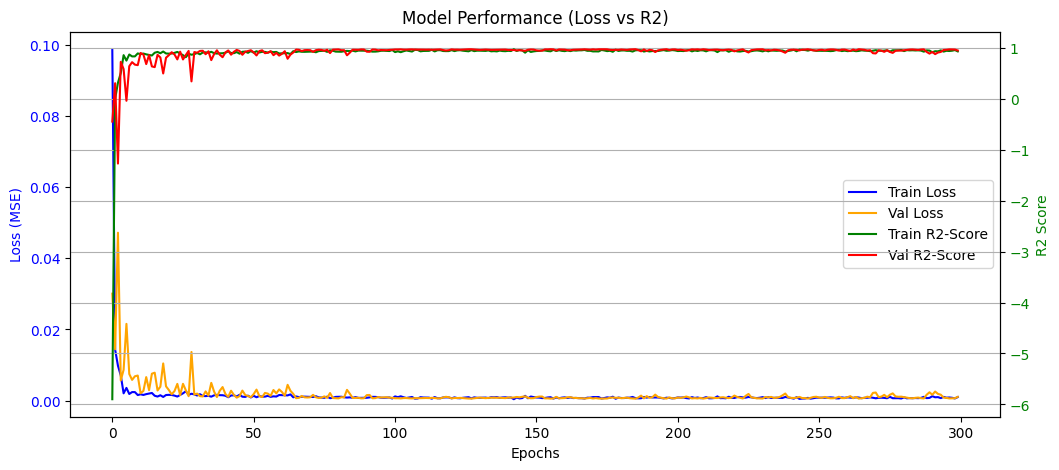

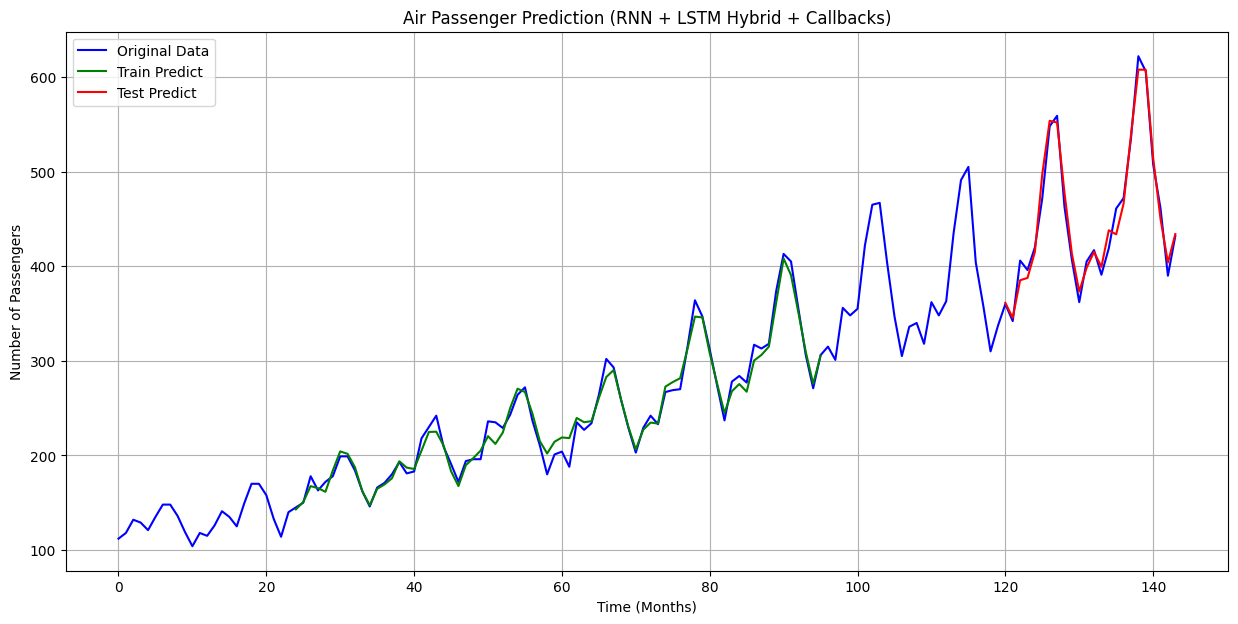

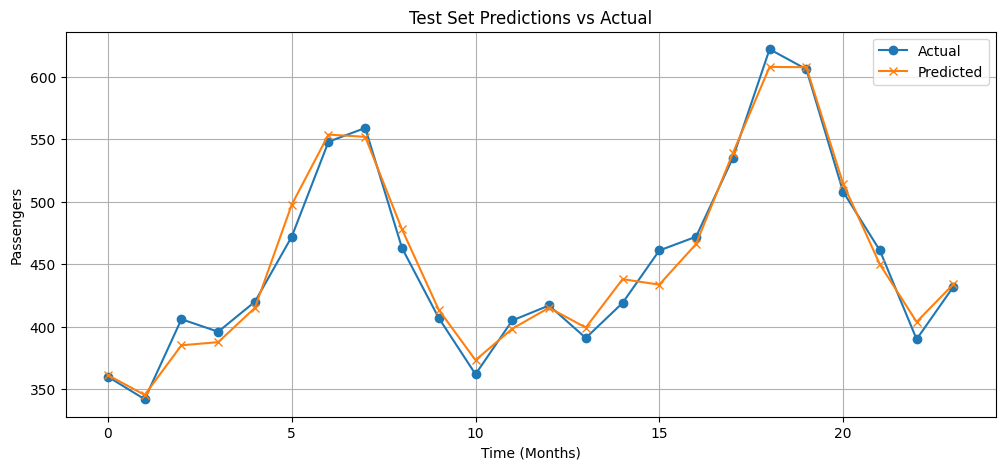

In [12]:
# 9. Visualization

fig, ax1 = plt.subplots(figsize=(12, 5))
# Left Y-axis - Loss
ax1.plot(history.history['loss'], label='Train Loss', color='blue')
ax1.plot(history.history['val_loss'], label='Val Loss', color='orange')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss (MSE)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
# Right Y-axis - R² Score
ax2 = ax1.twinx()
ax2.plot(history.history['r2_score'], label='Train R2-Score', color='green')
ax2.plot(history.history['val_r2_score'], label='Val R2-Score', color='red')
ax2.set_ylabel('R2 Score', color='green')
ax2.tick_params(axis='y', labelcolor='green')
# Legends
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='center right')
plt.title('Model Performance (Loss vs R2)')
plt.grid(True)
plt.show()

# Predictions vs Actual
plt.figure(figsize=(15, 7))
plt.plot(scaler.inverse_transform(dat), label='Original Data', color='blue')
plt.plot(range(look_back, look_back + len(train_pred)), train_pred, label='Train Predict', color='green')
plt.plot(range(len(dat) - len(test_pred), len(dat)), test_pred, label='Test Predict', color='red')
plt.title('Air Passenger Prediction (RNN + LSTM Hybrid + Callbacks)')
plt.xlabel('Time (Months)')
plt.ylabel('Number of Passengers')
plt.legend()
plt.grid(True)
plt.show()

# Test Set Comparison
plt.figure(figsize=(12, 5))
plt.plot(testY_inv, label='Actual', marker='o')
plt.plot(test_pred, label='Predicted', marker='x')
plt.title('Test Set Predictions vs Actual')
plt.xlabel('Time (Months)')
plt.ylabel('Passengers')
plt.legend()
plt.grid(True)
plt.show()

---
### 10. Saving the Model
**Explanation:**
- *What is done:* The trained model is saved to disk in two formats: the TensorFlow SavedModel format and the native Keras `.keras` format.
- *Why it's done:* Saving a trained model is crucial for deployment and reusability. It allows you to load the model later for inference without needing to retrain it from scratch.

In [13]:
# 10. Save for later use
model.export('model')
model.save('model.keras')

INFO:tensorflow:Assets written to: model\assets


INFO:tensorflow:Assets written to: model\assets


Saved artifact at 'model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 24, 1), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  2445089871760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2445089873680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2445089873488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2445089873872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2445089875024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2445089874256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2445089873104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2445089872912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2445089874640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2445089875600: TensorSpec(shape=(), dtype=tf.resource, name=None)
